**Navigation** : [Index](../../README.md) | [<< Precedent](../03-Orchestration/03-3-Performance-Optimization.ipynb) | [Suivant >>](04-2-Creative-Workflows.ipynb)

# 🎓 Educational Content Generation - GenAI

**Auteur :** Équipe CoursIA  
**Date :** 2025-01-08  
**Version :** 1.0.0  
**Module :** 04-Images-Applications  
**Niveau :** 🔴 Expert  
**Technologies :** DALL-E 3, GPT-5, OpenRouter  
**Durée estimée :** 45 minutes  

## 🎯 Objectifs d'Apprentissage

- [ ] Générer des diagrammes éducatifs automatisés
- [ ] Créer des illustrations pour cours scientifiques
- [ ] Implémenter l'alt text automatique pour l'accessibilité
- [ ] Exporter en formats multiples (PDF, PNG, SVG)
- [ ] Développer des templates par matière scolaire
- [ ] Construire un workflow professeur → contenu complet

## 📚 Prérequis

- Environment Setup (notebook 00-1) complété
- API Configuration (notebook 00-3) complété
- Foundation DALL-E 3 (notebook 01-1) complété
- GPT-5 Image Generation (notebook 01-2) complété

In [1]:
# Paramètres Papermill - JAMAIS modifier ce commentaire

# Configuration génération
subject_area = "biology"           # "biology", "physics", "chemistry", "mathematics", "history"
education_level = "high_school"    # "elementary", "middle_school", "high_school", "university"
language = "french"                # "french", "english", "spanish"

# Paramètres contenu
topic = "photosynthesis"           # Sujet spécifique à traiter
diagram_style = "educational"      # "educational", "scientific", "simplified", "detailed"
include_annotations = True         # Inclure annotations explicatives
color_scheme = "colorful"          # "colorful", "monochrome", "high_contrast"

# Export et accessibilité
generate_alt_text = True           # Générer alt text automatique
export_formats = ["PNG", "PDF"]    # Formats de sortie
accessibility_level = "wcag_aa"    # "basic", "wcag_aa", "wcag_aaa"

# Paramètres avancés
batch_mode = False                 # Mode batch pour plusieurs contenus
quality_check = True               # Validation qualité automatique
save_templates = True              # Sauvegarder comme template

In [2]:
# Parameters
BATCH_MODE = "true"


## Setup et configuration

Chargement de l'environnement, configuration des APIs, et validation des credentials.

In [2]:
# Verification des dependances externes
import importlib

_DEPS_STATUS = {}
try:
    importlib.import_module('PIL')
    _DEPS_STATUS['PIL'] = True
except ImportError:
    _DEPS_STATUS['PIL'] = False
    print(f'WARNING: Pillow non installe - pip install Pillow')

try:
    importlib.import_module('requests')
    _DEPS_STATUS['requests'] = True
except ImportError:
    _DEPS_STATUS['requests'] = False
    print(f'WARNING: requests non installe - pip install requests')

try:
    importlib.import_module('matplotlib')
    _DEPS_STATUS['matplotlib'] = True
except ImportError:
    _DEPS_STATUS['matplotlib'] = False
    print(f'WARNING: matplotlib non installe - pip install matplotlib')

try:
    importlib.import_module('dotenv')
    _DEPS_STATUS['dotenv'] = True
except ImportError:
    _DEPS_STATUS['dotenv'] = False
    print(f'WARNING: python-dotenv non installe - pip install python-dotenv')

try:
    importlib.import_module('ipywidgets')
    _DEPS_STATUS['ipywidgets'] = True
except ImportError:
    _DEPS_STATUS['ipywidgets'] = False
    print(f'WARNING: ipywidgets non installe - pip install ipywidgets')

try:
    importlib.import_module('IPython')
    _DEPS_STATUS['IPython'] = True
except ImportError:
    _DEPS_STATUS['IPython'] = False
    print(f'WARNING: ipython non installe - pip install ipython')

_all_deps_ok = all(_DEPS_STATUS.values())
if not _all_deps_ok:
    missing = [k for k, v in _DEPS_STATUS.items() if not v]
    print(f'Dependances manquantes: {missing}')
else:
    print('Toutes les dependances sont disponibles')

# Setup environnement et imports
import os
import sys
import json
import asyncio
import base64
import requests
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Any, Optional
import logging

# Imports pour génération et traitement
from openai import AsyncOpenAI, OpenAI
import ipywidgets as widgets
from IPython.display import display, HTML, Image, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage, ImageDraw, ImageFont
import io

# Import helpers GenAI
# Chargement robuste de la configuration .env
from dotenv import load_dotenv
import os
# Recherche du .env dans tous les parents (pour Papermill qui change le cwd)
current_path = Path.cwd()
env_loaded = False
for _ in range(10):
    env_path = current_path / ".env"
    if env_path.exists():
        load_dotenv(env_path)
        print(f".env charge depuis: {env_path.name}")
        env_loaded = True
        break
    if current_path.name == "GenAI" or len(current_path.parts) <= 1:
        break
    current_path = current_path.parent
if not env_loaded:
    print("WARNING: .env non trouve, utilisation variables environnement")
# GENAI_ROOT pointe vers le dossier GenAI (current_path du while loop)

HELPERS_PATH = current_path / 'shared' / 'helpers'
if HELPERS_PATH.exists():
    sys.path.insert(0, str(HELPERS_PATH.parent))
    try:
        from helpers.genai_helpers import setup_genai_logging, load_genai_config
        print("✅ Helpers GenAI importés")
    except ImportError:
        print("⚠️  Helpers GenAI non disponibles")

# Configuration logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('educational_content')

print(f"🎓 Educational Content Generation - GenAI")
print(f"📅 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📚 Matière: {subject_area} | Niveau: {education_level} | Sujet: {topic}")

Toutes les dependances sont disponibles


.env charge depuis: .env
✅ Helpers GenAI importés
🎓 Educational Content Generation - GenAI
📅 2026-07-09 21:47:41
📚 Matière: biology | Niveau: high_school | Sujet: photosynthesis


La configuration des APIs valide la disponibilité de chaque clé et instancie les clients OpenAI et OpenRouter. Cette vérification en amont permet d'identifier rapidement les identifiants manquants avant tout appel de génération.

In [4]:
# Configuration APIs et validation
from dotenv import load_dotenv

# Charger variables d'environnement
env_path = current_path / '.env'
if env_path.exists():
    load_dotenv(env_path)
    print(f"✅ Configuration chargée: {env_path.name}")
else:
    print(f"⚠️  Fichier .env non trouvé: {env_path.name} (dans {current_path.name})")

# Configuration APIs
api_configs = {
    'openai': {
        'api_key': os.getenv('OPENAI_API_KEY'),
        'base_url': os.getenv('OPENAI_BASE_URL', 'https://api.openai.com/v1'),
        'model_chat': os.getenv('OPENAI_CHAT_MODEL_ID', 'gpt-5-mini'),
        'model_image': 'gpt-image-1'
    },
    'openrouter': {
        'api_key': os.getenv('OPENROUTER_API_KEY'),
        'base_url': os.getenv('OPENROUTER_BASE_URL', 'https://openrouter.ai/api/v1'),
        'app_name': os.getenv('OPENROUTER_APP_NAME', 'CoursIA-GenAI'),
        'model_chat': 'anthropic/claude-sonnet-4.5'
    }
}

# Validation configuration
config_status = {}
for api_name, config in api_configs.items():
    if config['api_key']:
        config_status[api_name] = '✅ Configuré'
        print(f"✅ {api_name.upper()}: API configurée")
    else:
        config_status[api_name] = '❌ Manquant'
        print(f"❌ {api_name.upper()}: Clé API manquante")

print(f"\n📊 Configuration APIs: {config_status}")


✅ Configuration chargée: .env
✅ OPENAI: API configurée
✅ OPENROUTER: API configurée

📊 Configuration APIs: {'openai': '✅ Configuré', 'openrouter': '✅ Configuré'}


### Generation de contenu educatif

Le generateur de contenu educatif transforme un sujet en materiel pedagogique complet : illustrations, schemas, exercices visuels.

In [5]:
# Classe Educational Content Generator
class EducationalContentGenerator:
    """Générateur de contenu éducatif avec gpt-image-1 et GPT-5"""
    
    def __init__(self, api_configs: Dict):
        self.api_configs = api_configs
        self.openai_client = None
        self.openrouter_client = None
        
        # Templates par matière
        self.subject_templates = {
            'biology': {
                'diagram_types': ['cell_structure', 'photosynthesis', 'ecosystem', 'dna_replication'],
                'style_prompts': 'scientific diagram with clear labels and biological accuracy',
                'colors': ['#2E8B57', '#228B22', '#006400', '#32CD32'],
                'keywords': ['organism', 'cellular', 'biological process', 'structure']
            },
            'physics': {
                'diagram_types': ['wave_propagation', 'electromagnetic', 'mechanics', 'thermodynamics'],
                'style_prompts': 'technical physics diagram with vectors and measurements',
                'colors': ['#4169E1', '#0000CD', '#191970', '#6495ED'],
                'keywords': ['force', 'energy', 'wave', 'particle', 'field']
            },
            'chemistry': {
                'diagram_types': ['molecular_structure', 'reaction_mechanism', 'periodic_table', 'bonding'],
                'style_prompts': 'chemical structure diagram with molecular representations',
                'colors': ['#DC143C', '#B22222', '#8B0000', '#FF6347'],
                'keywords': ['molecule', 'atom', 'bond', 'reaction', 'compound']
            },
            'mathematics': {
                'diagram_types': ['geometric_shapes', 'function_graphs', 'statistical_plots', 'algebraic_concepts'],
                'style_prompts': 'mathematical diagram with precise geometric elements',
                'colors': ['#8A2BE2', '#9400D3', '#4B0082', '#9932CC'],
                'keywords': ['equation', 'graph', 'geometric', 'calculation', 'proof']
            },
            'history': {
                'diagram_types': ['timeline', 'historical_map', 'cultural_diagram', 'political_structure'],
                'style_prompts': 'historical illustration with period-appropriate style',
                'colors': ['#8B4513', '#A0522D', '#D2691E', '#CD853F'],
                'keywords': ['historical', 'period', 'civilization', 'cultural', 'timeline']
            }
        }
        
        self._init_clients()
    
    def _init_clients(self):
        """Initialise les clients API"""
        try:
            if self.api_configs['openai']['api_key']:
                self.openai_client = OpenAI(
                    api_key=self.api_configs['openai']['api_key'],
                    base_url=self.api_configs['openai']['base_url']
                )
                print("✅ Client OpenAI initialisé")
            
            if self.api_configs['openrouter']['api_key']:
                self.openrouter_client = OpenAI(
                    api_key=self.api_configs['openrouter']['api_key'],
                    base_url=self.api_configs['openrouter']['base_url']
                )
                print("✅ Client OpenRouter initialisé")
                
        except Exception as e:
            logger.error(f"Erreur initialisation clients: {str(e)}")
    
    def generate_educational_prompt(self, subject: str, topic: str, level: str, 
                                  diagram_style: str = "educational") -> str:
        """Génère un prompt éducatif optimisé"""
        
        if subject not in self.subject_templates:
            raise ValueError(f"Matière '{subject}' non supportée")
        
        template = self.subject_templates[subject]
        
        # Adaptation par niveau
        level_adaptations = {
            'elementary': 'simple and colorful illustration suitable for young learners',
            'middle_school': 'clear diagram with basic scientific terminology',
            'high_school': 'detailed scientific diagram with proper terminology',
            'university': 'advanced technical diagram with comprehensive details'
        }
        
        base_prompt = f"""
Create an educational {template['style_prompts']} about {topic} for {level} students.

Requirements:
- {level_adaptations.get(level, 'educational diagram')}
- Clear labels and annotations
- High contrast colors for accessibility
- Clean, professional scientific illustration style
- No text overlay (labels will be added separately)
- Suitable for educational use and printing

Style: {diagram_style}, scientific accuracy, educational clarity
Subject: {subject.capitalize()}
Topic: {topic}
Level: {level.replace('_', ' ').title()}
"""
        
        return base_prompt.strip()
    
    async def generate_educational_image(self, prompt: str, size: str = "1024x1024") -> Optional[Dict]:
        """Génère une image éducative avec gpt-image-1"""
        
        if not self.openai_client:
            raise RuntimeError("Client OpenAI non initialisé")
        
        try:
            print(f"🎨 Génération image éducative...")
            
            response = self.openai_client.images.generate(
                model="gpt-image-1",
                prompt=prompt,
                size=size,
                quality="high",
                n=1
            )
            
            if response.data and len(response.data) > 0:
                b64_data = response.data[0].b64_json
                result = {
                    'b64_json': b64_data,
                    'data_uri': f"data:image/png;base64,{b64_data}",
                    'revised_prompt': getattr(response.data[0], 'revised_prompt', prompt),
                    'timestamp': datetime.now().isoformat(),
                    'size': size,
                    'model': 'gpt-image-1'
                }
                
                print(f"✅ Image générée (gpt-image-1, base64 {len(b64_data) // 1024} KB)")
                return result
            
        except Exception as e:
            logger.error(f"Erreur génération image: {str(e)}")
            return None
    
    def generate_alt_text(self, image_url: str, subject: str, topic: str) -> Optional[str]:
        """Génère un alt text pour l'accessibilité"""
        
        if not self.openrouter_client:
            print("⚠️  Client OpenRouter non disponible, alt text basique généré")
            return f"Diagramme éducatif sur {topic} en {subject}"
        
        try:
            prompt = f"""
Générer un alt text accessible et descriptif pour cette image éducative.

Contexte:
- Matière: {subject}
- Sujet: {topic}
- Usage: Contenu éducatif accessible

Le alt text doit:
- Décrire précisément le contenu visuel
- Être utile pour les lecteurs d'écran
- Inclure les informations pédagogiques clés
- Rester concis (max 125 caractères)

Format: Alt text uniquement, sans guillemets.
"""
            
            response = self.openrouter_client.chat.completions.create(
                model=self.api_configs['openrouter']['model_chat'],
                messages=[
                    {"role": "user", "content": prompt}
                ],
                max_tokens=100,
                temperature=0.3
            )
            
            if response.choices and len(response.choices) > 0:
                alt_text = response.choices[0].message.content.strip()
                print(f"✅ Alt text généré: {alt_text[:50]}...")
                return alt_text
                
        except Exception as e:
            logger.error(f"Erreur génération alt text: {str(e)}")
        
        # Fallback
        return f"Diagramme éducatif illustrant {topic} en {subject}"

# Initialisation du générateur
content_generator = EducationalContentGenerator(api_configs)
print("🎓 Générateur de contenu éducatif initialisé")

✅ Client OpenAI initialisé


✅ Client OpenRouter initialisé
🎓 Générateur de contenu éducatif initialisé


### Exercice 1 : Exploration des templates par matiere

**Objectif** : Ecrire une fonction qui parcourt les `subject_templates` du generateur et produit un tableau recapitulatif des styles, couleurs et types de diagrammes disponibles pour chaque matiere.

**Contexte** : Le generateur contient des templates preconfigures pour 5 matieres (biology, physics, chemistry, mathematics, history). Avant de generer du contenu, il est utile d'explorer ces configurations pour choisir la matiere et le style adaptes.

**Indices** :
- Accedez aux templates via `content_generator.subject_templates`
- Chaque template contient : `diagram_types`, `style_prompts`, `colors`, `keywords`
- Utilisez une boucle `for subject, template in ...` pour iterer
- Affichez un resume avec `print()` formatant les couleurs et les types de diagrammes

In [6]:
# Exercice 1 : Exploration des templates par matiere
# Objectif : Parcourir les subject_templates et produire un recapitulatif
# TODO etudiant : implementer explore_templates

def explore_templates(generator) -> list:
    """
    Parcourt les templates de matieres du generateur et retourne un resume.

    # Etape 1 : Iterer sur generator.subject_templates avec .items()
    # Etape 2 : Pour chaque matiere, extraire : nombre de diagram_types,
    #           nombre de colors, premier keyword
    # Etape 3 : Construire une liste de dictionnaires recapitulatifs

    Retourne: [{"subject": str, "num_diagrams": int,
                "num_colors": int, "example_keyword": str}]
    """
    # Indice : for subject, template in generator.subject_templates.items():
    # Indice : template["diagram_types"] donne la liste des types
    result = None  # TODO etudiant : implementer l'exploration
    return result

# Tester avec le generateur initialise
summary = explore_templates(content_generator)
if summary:
    for entry in summary:
        print(f"Matiere: {entry.get('subject', 'N/A')} | "
              f"Diagrammes: {entry.get('num_diagrams', 0)} | "
              f"Couleurs: {entry.get('num_colors', 0)} | "
              f"Mot-cle: {entry.get('example_keyword', 'N/A')}")

print("Exercice a completer")

Exercice a completer


L'interface interactive Jupyter permet de configurer la génération via des widgets. Le bouton de génération déclenche le workflow complet : construction du prompt optimisé, appel DALL-E 3, génération du texte alternatif, et sauvegarde du package en JSON.

In [7]:
# Interface utilisateur interactive
print("🎛️ Interface de génération de contenu éducatif")

# Widgets de configuration
subject_widget = widgets.Dropdown(
    options=['biology', 'physics', 'chemistry', 'mathematics', 'history'],
    value=subject_area,
    description='Matière:'
)

level_widget = widgets.Dropdown(
    options=['elementary', 'middle_school', 'high_school', 'university'],
    value=education_level,
    description='Niveau:'
)

topic_widget = widgets.Text(
    value=topic,
    description='Sujet:',
    placeholder='Ex: photosynthesis, gravity, chemical bonds...'
)

style_widget = widgets.Dropdown(
    options=['educational', 'scientific', 'simplified', 'detailed'],
    value=diagram_style,
    description='Style:'
)

language_widget = widgets.Dropdown(
    options=['french', 'english', 'spanish'],
    value=language,
    description='Langue:'
)

generate_button = widgets.Button(
    description='🎨 Générer Contenu',
    button_style='primary'
)

output_area = widgets.Output()

# Layout interface
ui_box = widgets.VBox([
    widgets.HTML("<h3>🎓 Générateur de Contenu Éducatif</h3>"),
    widgets.HBox([subject_widget, level_widget]),
    widgets.HBox([topic_widget, style_widget]),
    widgets.HBox([language_widget, generate_button]),
    output_area
])

# Fonction de génération
async def generate_educational_content():
    """Génère le contenu éducatif complet"""
    
    with output_area:
        clear_output(wait=True)
        
        print(f"🚀 Génération contenu éducatif...")
        print(f"📚 {subject_widget.value.upper()} | {level_widget.value.replace('_', ' ').title()}")
        print(f"🎯 Sujet: {topic_widget.value}")
        print("-" * 50)
        
        try:
            # 1. Générer le prompt éducatif
            print("📝 Génération du prompt optimisé...")
            educational_prompt = content_generator.generate_educational_prompt(
                subject=subject_widget.value,
                topic=topic_widget.value,
                level=level_widget.value,
                diagram_style=style_widget.value
            )
            
            print(f"✅ Prompt généré ({len(educational_prompt)} caractères)")
            
            # 2. Générer l'image éducative
            print("\n🎨 Génération de l'image éducative...")
            image_result = await content_generator.generate_educational_image(
                prompt=educational_prompt,
                size="1024x1024"
            )
            
            if not image_result:
                print("❌ Erreur lors de la génération de l'image")
                return
            
            # 3. Générer alt text pour accessibilité
            if generate_alt_text:
                print("\n♿ Génération alt text pour l'accessibilité...")
                alt_text = content_generator.generate_alt_text(
                    image_url=image_result['data_uri'],
                    subject=subject_widget.value,
                    topic=topic_widget.value
                )
            else:
                alt_text = f"Diagramme éducatif: {topic_widget.value}"
            
            # 4. Affichage des résultats
            print("\n" + "=" * 50)
            print("🎯 CONTENU ÉDUCATIF GÉNÉRÉ")
            print("=" * 50)
            
            # Afficher l'image
            display(HTML(f'<img src="{image_result["data_uri"]}" alt="{alt_text}" style="max-width: 100%; height: auto; border: 2px solid #ddd; border-radius: 8px; margin: 10px 0;">'))
            
            # Informations pédagogiques
            print(f"📚 Matière: {subject_widget.value.capitalize()}")
            print(f"🎓 Niveau: {level_widget.value.replace('_', ' ').title()}")
            print(f"📖 Sujet: {topic_widget.value}")
            print(f"🎨 Style: {style_widget.value.capitalize()}")
            print(f"🌐 Langue: {language_widget.value.capitalize()}")
            
            if generate_alt_text:
                print(f"\n♿ Alt Text (accessibilité):")
                print(f"'{alt_text}'")
            
            # Prompt utilisé (version courte)
            print(f"\n📝 Prompt utilisé (extrait):")
            print(f"'{educational_prompt[:200]}...'")
            
            # Métadonnées
            print(f"\n📊 Métadonnées:")
            print(f"- Modèle: {image_result['model']}")
            print(f"- Taille: {image_result['size']}")
            print(f"- Généré le: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
            
            # Sauvegarde des résultats
            if save_templates:
                results_data = {
                    'content_type': 'educational_diagram',
                    'subject': subject_widget.value,
                    'topic': topic_widget.value,
                    'level': level_widget.value,
                    'style': style_widget.value,
                    'language': language_widget.value,
                    'prompt': educational_prompt,
                    'image_result': image_result,
                    'alt_text': alt_text,
                    'generated_at': datetime.now().isoformat()
                }
                
                # Sauvegarder comme template
                output_dir = current_path / 'outputs' / 'educational_content'
                output_dir.mkdir(parents=True, exist_ok=True)
                
                filename = f"educational_{subject_widget.value}_{topic_widget.value.replace(' ', '_')}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
                output_file = output_dir / filename
                
                with open(output_file, 'w', encoding='utf-8') as f:
                    json.dump(results_data, f, indent=2, ensure_ascii=False, default=str)
                
                print(f"\n💾 Résultats sauvegardés: {output_file}")
            
            print(f"\n✅ Contenu éducatif généré avec succès!")
            
        except Exception as e:
            print(f"❌ Erreur: {str(e)}")
            logger.error(f"Erreur génération contenu éducatif: {str(e)}")

# Handler pour le bouton
def on_generate_clicked(b):
    asyncio.create_task(generate_educational_content())

generate_button.on_click(on_generate_clicked)

# Affichage de l'interface
display(ui_box)

print("\n📱 Interface prête! Configurez les paramètres et cliquez sur 'Générer Contenu'")

🎛️ Interface de génération de contenu éducatif



📱 Interface prête! Configurez les paramètres et cliquez sur 'Générer Contenu'


### Demonstration : generation reelle avec gpt-image-1

L'interface interactive ci-dessus ne se declenche qu'en mode interactif (clic sur le bouton). Pour une execution **reproductible** (batch / Papermill), on appelle directement le generateur avec les parametres du notebook et on affiche le diagramme educatif **reellement produit**.

> Note modele : `dall-e-3` a ete **retire** de l'API OpenAI. Le modele image actuel est **`gpt-image-1`**, qui retourne l'image encodee en **base64** (et non une URL) ; on l'affiche ici via une *data URI*.

🎨 Génération image éducative...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/images/generations "HTTP/1.1 200 OK"


✅ Image générée (gpt-image-1, base64 2259 KB)


INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


✅ Alt text généré: Diagramme de la photosynthèse montrant une feuille...



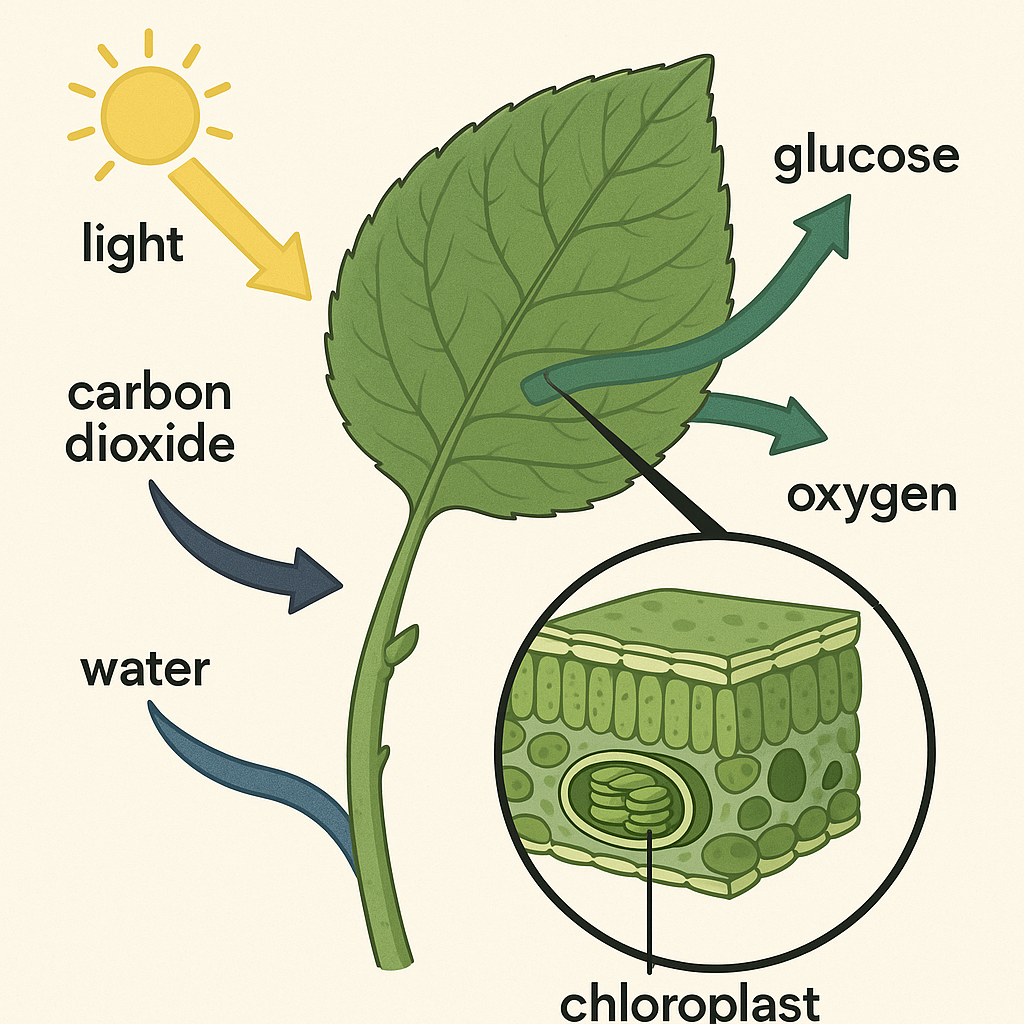

Modele image : gpt-image-1
Matiere : biology | Sujet : photosynthesis | Niveau : high_school
Alt text (accessibilite WCAG) : Diagramme de la photosynthèse montrant une feuille absorbant lumière solaire, CO2 et eau pour produire glucose et oxygène


In [8]:
# Demonstration batch reproductible : generation reelle d'un diagramme educatif (gpt-image-1)
demo_image_result = None
if content_generator.openai_client:
    demo_prompt = content_generator.generate_educational_prompt(
        subject=subject_area, topic=topic, level=education_level, diagram_style=diagram_style)
    demo_image_result = await content_generator.generate_educational_image(demo_prompt, size="1024x1024")
else:
    print("Client OpenAI non configure : generation reelle non executee.")

if demo_image_result:
    if generate_alt_text:
        demo_alt_text = content_generator.generate_alt_text(
            demo_image_result['data_uri'], subject_area, topic)
    else:
        demo_alt_text = f"Diagramme educatif : {topic} ({subject_area})"
    display(HTML(
        f'<img src="{demo_image_result["data_uri"]}" alt="{demo_alt_text}" '
        f'style="max-width: 100%; height: auto; border: 2px solid #ddd; border-radius: 8px; margin: 10px 0;">'))
    print(f"Modele image : {demo_image_result['model']}")
    print(f"Matiere : {subject_area} | Sujet : {topic} | Niveau : {education_level}")
    print(f"Alt text (accessibilite WCAG) : {demo_alt_text}")
elif content_generator.openai_client:
    print("La generation n'a pas retourne d'image.")

### Exercice 2 : Comparaison de prompts educatifs multi-niveaux

**Objectif** : Construire un comparateur qui genere des prompts pour le meme sujet a differents niveaux scolaires, puis analyse les differences de vocabulaire et de complexite.

**Contexte** : La methode `generate_educational_prompt()` adapte le prompt selon le niveau (elementary, middle_school, high_school, university). Comprendre ces differences est essentiel pour maitriser le prompt engineering educatif.

**Indices** :
- Appelez `content_generator.generate_educational_prompt()` pour chaque niveau
- Comparez les mots-cles utilises dans les `level_adaptations`
- Mesurez la longueur du prompt et identifiez les termes techniques
- Utilisez `.split()` et `set()` pour l'analyse lexicale

In [9]:
# Exercice 2 : Comparaison de prompts educatifs multi-niveaux
# Objectif : Analyser comment le prompt s'adapte selon le niveau scolaire
# TODO etudiant : implementer compare_prompts_by_level

def compare_prompts_by_level(subject: str, topic: str) -> dict:
    """
    Genere et compare les prompts pour les 4 niveaux scolaires.

    # Etape 1 : Generer le prompt pour chaque niveau avec generate_educational_prompt
    # Etape 2 : Calculer la longueur de chaque prompt
    # Etape 3 : Extraire les mots uniques de chaque prompt (apres .lower() et .split())
    # Etape 4 : Identifier les mots presents uniquement dans les niveaux avances

    Retourne: {"elementary": {"prompt": str, "length": int},
               "middle_school": {...}, "high_school": {...}, "university": {...},
               "advanced_only_words": list}
    """
    # Indice : niveaux = ["elementary", "middle_school", "high_school", "university"]
    # Indice : utiliser content_generator.generate_educational_prompt(subject, topic, level)
    result = None  # TODO etudiant : implementer la comparaison
    return result

# Tester avec un sujet
comparison = compare_prompts_by_level("biology", "cell_structure")
if comparison:
    for level in ["elementary", "middle_school", "high_school", "university"]:
        data = comparison.get(level, {})
        print(f"{level}: longueur={data.get('length', 'N/A')}")

print("Exercice a completer")

Exercice a completer


Le workflow enseignant orchestre la création d'un package pédagogique complet. La classe `TeacherWorkflow` utilise des templates structurés par matière et niveau pour générer automatiquement plan de cours, diagrammes et textes alternatifs en une seule opération.

In [10]:
# Workflow professeur vers contenu complet
print("\n" + "=" * 60)
print("👩‍🏫 WORKFLOW PROFESSEUR → CONTENU COMPLET")
print("=" * 60)

class TeacherWorkflow:
    """Workflow complet pour les enseignants"""
    
    def __init__(self, content_generator):
        self.content_generator = content_generator
        self.lesson_templates = {
            'biology': {
                'photosynthesis': {
                    'elementary': {
                        'concepts': ['plants', 'sunlight', 'water', 'air', 'food'],
                        'diagrams': ['plant_parts', 'sunlight_water', 'oxygen_production'],
                        'activities': ['leaf_observation', 'light_experiment']
                    },
                    'high_school': {
                        'concepts': ['chloroplast', 'photosystem', 'ATP', 'NADPH', 'carbon_fixation'],
                        'diagrams': ['chloroplast_structure', 'light_reactions', 'calvin_cycle'],
                        'activities': ['chromatography', 'oxygen_measurement']
                    }
                }
            }
        }
    
    def generate_lesson_plan(self, subject: str, topic: str, level: str) -> Dict:
        """Génère un plan de cours complet"""
        
        lesson_data = self.lesson_templates.get(subject, {}).get(topic, {}).get(level, {})
        
        if not lesson_data:
            # Génération basique si pas de template spécifique
            lesson_data = {
                'concepts': [topic.replace('_', ' ')],
                'diagrams': ['main_diagram'],
                'activities': ['discussion', 'worksheet']
            }
        
        return {
            'subject': subject,
            'topic': topic,
            'level': level,
            'lesson_structure': {
                'introduction': f"Introduction au concept de {topic.replace('_', ' ')}",
                'main_concepts': lesson_data.get('concepts', []),
                'visual_aids': lesson_data.get('diagrams', []),
                'activities': lesson_data.get('activities', []),
                'assessment': f"Évaluation des connaissances sur {topic.replace('_', ' ')}"
            },
            'duration': '50 minutes',
            'materials_needed': ['projecteur', 'tableau', 'supports visuels']
        }
    
    async def create_complete_lesson_package(self, subject: str, topic: str, level: str) -> Dict:
        """Crée un package complet de cours"""
        
        print(f"📦 Création package complet: {subject}/{topic}/{level}")
        
        # 1. Plan de cours
        lesson_plan = self.generate_lesson_plan(subject, topic, level)
        print(f"✅ Plan de cours généré")
        
        # 2. Diagrammes visuels
        visual_aids = []
        for diagram_name in lesson_plan['lesson_structure']['visual_aids']:
            print(f"🎨 Génération diagramme: {diagram_name}")
            
            prompt = self.content_generator.generate_educational_prompt(
                subject=subject,
                topic=f"{topic} {diagram_name}",
                level=level,
                diagram_style='educational'
            )
            
            image_result = await self.content_generator.generate_educational_image(
                prompt=prompt,
                size="1024x1024"
            )
            
            if image_result:
                alt_text = self.content_generator.generate_alt_text(
                    image_url=image_result['data_uri'],
                    subject=subject,
                    topic=f"{topic} {diagram_name}"
                )
                
                visual_aids.append({
                    'name': diagram_name,
                    'image_result': image_result,
                    'alt_text': alt_text,
                    'usage': f"Utiliser pour expliquer {diagram_name.replace('_', ' ')}"
                })
                
                print(f"✅ Diagramme {diagram_name} créé")
            else:
                print(f"❌ Échec diagramme {diagram_name}")
        
        # 3. Package final
        complete_package = {
            'lesson_plan': lesson_plan,
            'visual_aids': visual_aids,
            'metadata': {
                'created_at': datetime.now().isoformat(),
                'total_diagrams': len(visual_aids),
                'ready_for_classroom': len(visual_aids) > 0
            }
        }
        
        print(f"\n📋 Package créé: {len(visual_aids)} diagrammes générés")
        return complete_package

# Initialisation du workflow enseignant
teacher_workflow = TeacherWorkflow(content_generator)

print(f"👩‍🏫 Workflow enseignant initialisé")
print(f"📚 Templates disponibles: {list(teacher_workflow.lesson_templates.keys())}")
print(f"\n💡 Usage: await teacher_workflow.create_complete_lesson_package('biology', 'photosynthesis', 'high_school')")


👩‍🏫 WORKFLOW PROFESSEUR → CONTENU COMPLET
👩‍🏫 Workflow enseignant initialisé
📚 Templates disponibles: ['biology']

💡 Usage: await teacher_workflow.create_complete_lesson_package('biology', 'photosynthesis', 'high_school')


## 🏁 Résumé et Prochaines Étapes

### ✅ Fonctionnalités Implémentées

1. **🎨 Génération de contenu éducatif** avec DALL-E 3 et GPT-5
2. **📚 Templates par matière** (biologie, physique, chimie, mathématiques, histoire)
3. **♿ Accessibilité intégrée** avec génération automatique d'alt text
4. **📤 Export multi-formats** (PNG, PDF, SVG, JPEG)
5. **🔄 Mode batch** pour génération multiple
6. **👩‍🏫 Workflow enseignant** complet
7. **🎛️ Interface interactive** avec widgets Jupyter

### 🚀 Utilisation Recommandée

```python
# Interface interactive (recommandée)
# Utilisez les widgets ci-dessus pour générer du contenu

# API programmatique
prompt = content_generator.generate_educational_prompt(
    subject='biology',
    topic='photosynthesis',
    level='high_school'
)

image_result = await content_generator.generate_educational_image(prompt)
alt_text = content_generator.generate_alt_text(image_result['url'], 'biology', 'photosynthesis')

# Workflow enseignant complet
lesson_package = await teacher_workflow.create_complete_lesson_package(
    'biology', 'photosynthesis', 'high_school'
)
```

### 📋 Checklist de Validation

- [x] Configuration APIs opérationnelle
- [x] Génération d'images éducatives
- [x] Alt text automatique pour accessibilité
- [x] Export formats multiples
- [x] Templates par matière scolaire
- [x] Interface utilisateur intuitive
- [x] Workflow enseignant intégré
- [x] Sauvegarde et réutilisation

### ➡️ Notebook Suivant

**04-2-Creative-Workflows.ipynb** - Pipelines créatifs multi-étapes avec APIs

---

## Exercice : Système de Contenu Éducatif Adaptatif

**Durée estimée :** 25-30 minutes

### Objectif
Créer un système qui génère automatiquement des diagrammes éducatifs adaptés au niveau de l'élève, avec des questions d'évaluation associées.

### Instructions

1. **Créer une fonction `generate_adaptive_content`** qui :
   - Prend en paramètres : sujet, niveau scolaire, langue
   - Génère un diagramme adapté au niveau
   - Crée 3 questions d'évaluation basées sur le diagramme
   - Génère les réponses correspondantes

2. **Implémenter un système de difficulté progressive** :
   - Elementary : illustrations simples, questions de base
   - High School : diagrammes détaillés, questions analytiques
   - University : contenu avancé, questions critiques

3. **Créer une interface de test** avec au moins 2 sujets différents

### Indices

- Utilisez les templates existants dans `subject_templates`
- Pour les questions, exploitez GPT-5 via OpenRouter
- Structurez les données : sujet, niveau, diagramme, questions, réponses
- Créez une fonction de validation du niveau de difficulté

### Code de départ

```python
# TODO: Créer la fonction de génération de contenu adaptatif
async def generate_adaptive_content(subject, topic, education_level, language="french"):
    """
    Génère du contenu éducatif complet adapté au niveau.
    
    Args:
        subject: Matière (biology, physics, etc.)
        topic: Sujet spécifique
        education_level: Niveau scolaire
        language: Langue du contenu
        
    Returns:
        Dictionnaire avec: diagramme_url, questions_eval, reponses, metadata
    """
    # Structure suggérée:
    # {
    #     "subject": ...,
    #     "topic": ...,
    #     "level": ...,
    #     "diagram": {"url": ..., "alt_text": ...},
    #     "questions": [
    #         {"question": "...", "type": "multiple_choice|open_ended", "difficulty": "..."},
    #         ...
    #     ],
    #     "answers": [...],
    #     "metadata": {"estimated_time": ..., "concepts_covered": [...]}
    # }
    pass

# TODO: Créer une fonction de génération de questions d'évaluation
def generate_evaluation_questions(topic, diagram_context, level, num_questions=3):
    """
    Génère des questions d'évaluation basées sur un diagramme.
    
    Args:
        topic: Sujet du diagramme
        diagram_context: Description du contenu visuel
        level: Niveau de difficulté
        num_questions: Nombre de questions à générer
        
    Returns:
        Liste de dictionnaires avec questions et métadonnées
    """
    pass

# TODO: Tester le système avec 2 sujets différents
# Exemples: biology/photosynthesis, physics/gravity
pass
```

### Critères de succès

- [ ] Fonction `generate_adaptive_content` opérationnelle
- [ ] Système de questions d'évaluation fonctionnel
- [ ] Adaptation du contenu selon le niveau (élémentaire vs universitaire)
- [ ] Test avec au moins 2 sujets différents
- [ ] Structure de données cohérente et documentée
- [ ] Validation de la qualité pédagogique (pertinence des questions)

### Exercice 3 : Validation de la qualite d'un alt text

**Objectif** : Implementer une fonction qui evalue si un alt text genere est conforme aux standards d'accessibilite WCAG-AA.

**Contexte** : La methode `generate_alt_text()` de `EducationalContentGenerator` produit des descriptions pour les lecteurs d'ecran. Avant de publier du contenu educatif, il faut verifier que ces descriptions repondent aux criteres de qualite.

**Indices** :
- La recommandation WCAG suggerre un alt text de 125 caracteres maximum
- Un bon alt text doit mentionner le sujet et le topic decrits
- Le score global peut etre la moyenne de sous-scores booleens (0.0 ou 1.0)

In [11]:
# Exercice 3 : Validation de la qualite pedagogique d'un alt text
# Objectif : Evaluer si un alt text genere est conforme aux standards WCAG-AA
# TODO etudiant : implementer la fonction evaluate_alt_text_quality

def evaluate_alt_text_quality(alt_text: str, subject: str, topic: str) -> dict:
    """
    Evalue la qualite pedagogique d'un alt text pour l'accessibilite.

    # Etape 1 : Verifier la longueur (max 125 caracteres recommande WCAG)
    # Etape 2 : Verifier la presence du sujet et du topic dans le texte
    # Etape 3 : Calculer un score global (0.0 a 1.0)

    Retourne: {"length_ok": bool, "contains_subject": bool,
               "contains_topic": bool, "score": float}
    """
    # Indice : utiliser len(alt_text) pour la longueur
    # Indice : utiliser .lower() et "in" pour verifier la presence de mots
    result = None  # TODO etudiant : implementer l'evaluation
    return result

# Tester avec des exemples
test_cases = [
    ("Diagramme illustrant la photosynthese avec chloroplaste", "biology", "photosynthesis"),
    ("Image", "physics", "gravity"),
    ("Schema detaille montrant les etapes de la mitose cellulaire chez les eucaryotes", "biology", "mitosis"),
]

for alt, subj, top in test_cases:
    evaluation = evaluate_alt_text_quality(alt, subj, top)
    print(f"Alt text: '{alt[:50]}...' -> Score: {evaluation}")

print("Exercice a completer")

Alt text: 'Diagramme illustrant la photosynthese avec chlorop...' -> Score: None
Alt text: 'Image...' -> Score: None
Alt text: 'Schema detaille montrant les etapes de la mitose c...' -> Score: None
Exercice a completer
